In [75]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from pathlib import Path

In [76]:
project_path = Path("/Users/irinafendley/Projects/Loan_Default")

df = pd.read_csv(
    project_path / "data/processed/loan_clean.csv"
)

In [77]:
model = joblib.load(
    project_path / "data/models/logistic_regression.pkl"
)

In [78]:
print(model.feature_names_in_)

['Age' 'Income' 'LoanAmount' 'CreditScore' 'MonthsEmployed'
 'NumCreditLines' 'InterestRate' 'LoanTerm' 'DTIRatio' 'HasMortgage'
 'HasDependents' 'HasCoSigner' 'Income_to_Loan' 'Debt_burden'
 'Score_pressure' 'Risk_rate' 'Risk_score' 'Education_High School'
 "Education_Master's" 'Education_PhD' 'EmploymentType_Part-time'
 'EmploymentType_Self-employed' 'EmploymentType_Unemployed'
 'MaritalStatus_Married' 'MaritalStatus_Single' 'LoanPurpose_Business'
 'LoanPurpose_Education' 'LoanPurpose_Home' 'LoanPurpose_Other']


In [79]:
# recreate engineered features used during model training

df["Income_to_Loan"] = (
    df["Income"] /
    (df["LoanAmount"] + 1)
)

df["Debt_burden"] = (
    df["LoanAmount"] /
    (df["Income"] + 1)
)

df["Score_pressure"] = (
    df["LoanAmount"] /
    (df["CreditScore"] + 1)
)

df["Risk_rate"] = (
    df["InterestRate"]
    *
    df["DTIRatio"]
)

df["Risk_score"] = (
    df["InterestRate"] * 2
    +
    df["DTIRatio"] * 2
)

df_model = df.drop("LoanID", axis=1)

X = df_model.drop("Default", axis=1)

X = pd.get_dummies(
    X,
    drop_first=True
)

X = X.reindex(
    columns=model.feature_names_in_,
    fill_value=0
)

df["Probability_of_Default"] = (
    model.predict_proba(X)[:, 1]
)

df["IncomeSegment"] = pd.qcut(
    df["Income"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [80]:
print(df.columns.tolist())

['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default', 'Income_to_Loan', 'Debt_burden', 'Score_pressure', 'Risk_rate', 'Risk_score', 'Probability_of_Default', 'IncomeSegment']


In [82]:
print(
    df[
        [
            "Income",
            "LoanAmount",
            "Probability_of_Default",
            "IncomeSegment"
        ]
    ].head()
)

   Income  LoanAmount  Probability_of_Default IncomeSegment
0   85994       50587                0.036164          High
1   50432      124440                0.028946        Medium
2   84208      129188                0.164033          High
3   31713       44799                0.117799           Low
4   20437        9139                0.035242           Low


In [83]:
# borrowers who defaulted

defaulted = df[
    df["Default"] == 1
].copy()

print("Defaulted borrowers:")
print(len(defaulted))

Defaulted borrowers:
29653


In [84]:
term_summary = (
    defaulted["LoanTerm"]
    .value_counts()
    .sort_index()
)

print("\nNumber of defaulted borrowers by loan term")
print(term_summary)


Number of defaulted borrowers by loan term
LoanTerm
12    5920
24    5921
36    5907
48    5922
60    5983
Name: count, dtype: int64


In [85]:
term_pct = (
    defaulted["LoanTerm"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nPercentage distribution of defaulted borrowers by loan term")
print(term_pct.round(2))


Percentage distribution of defaulted borrowers by loan term
LoanTerm
12    19.96
24    19.97
36    19.92
48    19.97
60    20.18
Name: proportion, dtype: float64


In [86]:
portfolio_term_pct = (
    df["LoanTerm"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nShare of total portfolio by loan term (%)")
print(portfolio_term_pct.round(2))


Share of total portfolio by loan term (%)
LoanTerm
12    19.96
24    19.98
36    20.00
48    20.04
60    20.03
Name: proportion, dtype: float64


In [87]:
defaulted.groupby("LoanTerm").agg(
    Borrowers=("LoanAmount", "count"),
    AvgIncome=("Income", "mean"),
    AvgLoan=("LoanAmount", "mean"),
    AvgCreditScore=("CreditScore", "mean")
).round(2)

,Borrowers,AvgIncome,AvgLoan,AvgCreditScore
LoanTerm,,,,
12,5920,71762.83,145100.69,557.80
24,5921,72344.06,144289.65,560.94
36,5907,71249.59,145529.05,560.64
48,5922,71782.35,143852.75,561.85
60,5983,72080.89,143814.37,555.25


In [88]:
print("\nDefault rate by Loan Term")

default_rate_by_term = (
    df
    .groupby("LoanTerm")["Default"]
    .mean()
    * 100
)

print(default_rate_by_term.round(2))


Default rate by Loan Term
LoanTerm
12    11.62
24    11.61
36    11.57
48    11.57
60    11.70
Name: Default, dtype: float64


In [89]:
df["IncomeSegment"] = pd.qcut(
    df["Income"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)



In [90]:
# How much loan exposure exists in the highest-risk income segment?
low_income = df[
    df["IncomeSegment"] == "Low"
]

print("\nLow-income borrower summary")

print(
    low_income[
        [
            "LoanAmount",
            "Probability_of_Default"
        ]
    ].describe()
)


Low-income borrower summary
          LoanAmount  Probability_of_Default
count   63837.000000            63837.000000
mean   127624.499084                0.176560
std     70711.929137                0.149720
min      5005.000000                0.004709
25%     66240.000000                0.065916
50%    127810.000000                0.129772
75%    188926.000000                0.242468
max    249993.000000                0.929314


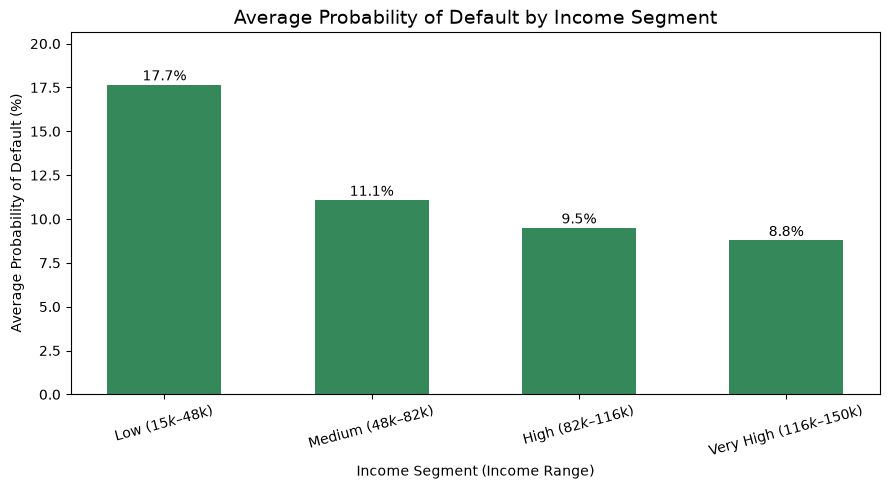

In [91]:

# Create readable labels with income ranges
income_labels = {
    "Low": "Low ($15k–$48k)",
    "Medium": "Medium ($48k–$82k)",
    "High": "High ($82k–$116k)",
    "Very High": "Very High ($116k–$150k)"
}

# Apply mapping to index
plot_index = risk_by_income.index.map(income_labels)

# ==========================
# Visualization
# ==========================

fig, ax = plt.subplots(figsize=(9,5))

bars = ax.bar(
    plot_index,
    risk_by_income["AvgPD"],
    width=0.55,
    color="#358859"
)

# value labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.25,
        f"{height:.1f}%",
        ha="center",
        fontsize=10
    )

ax.set_title("Average Probability of Default by Income Segment", fontsize=14)
ax.set_xlabel("Income Segment (Income Range)")
ax.set_ylabel("Average Probability of Default (%)")
ax.set_ylim(0, risk_by_income["AvgPD"].max() + 3)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    project_path / "visuals" / "income_segment_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
# For Low Income borrowers, reduce loan amount by 10%.

simulation = low_income.copy()

simulation["NewLoanAmount"] = (
    simulation["LoanAmount"] * 0.90
)

In [93]:
# Total loan exposure before and after the proposed policy

current_exposure = simulation["LoanAmount"].sum()

new_exposure = simulation["NewLoanAmount"].sum()

reduction = current_exposure - new_exposure

print("\nLoan Exposure")

print(f"Current exposure : ${current_exposure:,.0f}")
print(f"New exposure     : ${new_exposure:,.0f}")
print(f"Reduction        : ${reduction:,.0f}")


Loan Exposure
Current exposure : $8,147,165,148
New exposure     : $7,332,448,633
Reduction        : $814,716,515


In [94]:
# Expected loss under the current lending policy

simulation["CurrentExpectedLoss"] = (
    simulation["Probability_of_Default"]
    *
    simulation["LoanAmount"]
)

# Expected loss after reducing loan amounts by 10%

simulation["NewExpectedLoss"] = (
    simulation["Probability_of_Default"]
    *
    simulation["NewLoanAmount"]
)

In [51]:
current_loss = simulation["CurrentExpectedLoss"].sum()

new_loss = simulation["NewExpectedLoss"].sum()

loss_reduction = current_loss - new_loss

print("\nExpected Portfolio Loss")

print(f"Current expected loss : ${current_loss:,.0f}")
print(f"Expected loss after policy : ${new_loss:,.0f}")
print(f"Expected loss reduction : ${loss_reduction:,.0f}")


Expected Portfolio Loss
Current expected loss : $1,732,430,116
Expected loss after policy : $1,559,187,104
Expected loss reduction : $173,243,012


In [52]:
# How much expected loss is reduced for every $1 of lending reduced

risk_reduction_ratio = (
    loss_reduction
    /
    reduction
)

print("\nPolicy Efficiency")

print(f"Expected loss reduction per $1 of reduced lending: ${risk_reduction_ratio:.3f}")
print(f"This means every $1 not issued reduces expected losses by about {risk_reduction_ratio * 100:.1f} cents.")


Policy Efficiency
Expected loss reduction per $1 of reduced lending: $0.213
This means every $1 not issued reduces expected losses by about 21.3 cents.


In [53]:
current_avg = simulation["LoanAmount"].mean()
new_avg = simulation["NewLoanAmount"].mean()

print("\nAverage Loan Amount")

print(f"Current average loan: ${current_avg:,.0f}")
print(f"New average loan: ${new_avg:,.0f}")
print(f"Reduction per borrower: ${current_avg - new_avg:,.0f}")


Average Loan Amount
Current average loan: $127,624
New average loan: $114,862
Reduction per borrower: $12,762


In [54]:
# Compare lending reduction with expected loss reduction

net_difference = reduction - loss_reduction

loss_reduction_pct = (
    loss_reduction
    / reduction
    * 100
)

print("\nBusiness Impact")

print(f"Loan exposure reduced        : ${reduction:,.0f}")
print(f"Expected loss reduction      : ${loss_reduction:,.0f}")
print(f"Net reduction in lending     : ${net_difference:,.0f}")
print(f"Loss reduction equals        : {loss_reduction_pct:.1f}% of the lending reduction")


Business Impact
Loan exposure reduced        : $814,716,515
Expected loss reduction      : $173,243,012
Net reduction in lending     : $641,473,503
Loss reduction equals        : 21.3% of the lending reduction


In [55]:
# ============================================================
# Strategy 2
# High-risk borrowers:
# - Low Income
# - Credit Score below 350
# - DTI ratio above 0.60
# ============================================================

high_risk = df[
    (df["IncomeSegment"] == "Low")
    &
    (df["CreditScore"] < 350)
    &
    (df["DTIRatio"] > 0.60)
].copy()

In [56]:
print("\nHigh-risk borrower profile")
print("--------------------------------")

print(f"Borrowers: {len(high_risk):,}")

print(f"Average income: ${high_risk['Income'].mean():,.0f}")
print(f"Average loan amount: ${high_risk['LoanAmount'].mean():,.0f}")
print(f"Average credit score: {high_risk['CreditScore'].mean():.0f}")
print(f"Average DTI: {high_risk['DTIRatio'].mean():.2f}")

print(f"Average predicted default probability: {high_risk['Probability_of_Default'].mean()*100:.2f}%")

print(f"Observed default rate: {high_risk['Default'].mean()*100:.2f}%")


High-risk borrower profile
--------------------------------
Borrowers: 2,109
Average income: $32,256
Average loan amount: $127,224
Average credit score: 325
Average DTI: 0.75
Average predicted default probability: 21.75%
Observed default rate: 20.63%


In [65]:

# Reduce approved loan amount by 10%

print("\nPolicy Simulation: Loan Cap = -10%")
print("-----------------------------------")

# reduce loan size
high_risk["NewLoanAmount"] = high_risk["LoanAmount"] * 0.90

# exposure
current_exposure = high_risk["LoanAmount"].sum()
new_exposure = high_risk["NewLoanAmount"].sum()
reduction = current_exposure - new_exposure

print(f"Current exposure      : ${current_exposure:,.0f}")
print(f"New exposure          : ${new_exposure:,.0f}")
print(f"Exposure reduced      : ${reduction:,.0f}")


Policy Simulation: Loan Cap = -10%
-----------------------------------
Current exposure      : $268,315,030
New exposure          : $241,483,527
Exposure reduced      : $26,831,503


In [66]:
# expected loss BEFORE policy
high_risk["CurrentEL"] = (
    high_risk["LoanAmount"] * high_risk["Probability_of_Default"]
)

# expected loss AFTER policy
high_risk["NewEL"] = (
    high_risk["NewLoanAmount"] * high_risk["Probability_of_Default"]
)

current_loss = high_risk["CurrentEL"].sum()
new_loss = high_risk["NewEL"].sum()
loss_reduction = current_loss - new_loss

print("\nRisk Impact")
print("-----------")
print(f"Current expected loss  : ${current_loss:,.0f}")
print(f"New expected loss      : ${new_loss:,.0f}")
print(f"Loss reduced           : ${loss_reduction:,.0f}")


Risk Impact
-----------
Current expected loss  : $67,431,403
New expected loss      : $60,688,263
Loss reduced           : $6,743,140


In [67]:
efficiency = loss_reduction / reduction

print("\nBusiness Impact")
print("----------------")

print(f"Borrowers affected        : {len(high_risk):,}")
print(f"Loan exposure reduced     : ${reduction:,.0f}")
print(f"Expected loss reduced     : ${loss_reduction:,.0f}")
print(f"Efficiency of policy      : {efficiency*100:.1f}%")


Business Impact
----------------
Borrowers affected        : 2,109
Loan exposure reduced     : $26,831,503
Expected loss reduced     : $6,743,140
Efficiency of policy      : 25.1%


In [68]:

# HIGH-RISK POLICY SIMULATION (-20% cap)

high_risk = df[
    (df["IncomeSegment"] == "Low") &
    (df["CreditScore"] < 350) &
    (df["DTIRatio"] > 0.60)
].copy()

print("\nHigh-risk segment (-20% cap simulation)")
print("----------------------------------------")
print(f"Borrowers affected : {len(high_risk):,}")

high_risk["NewLoanAmount"] = high_risk["LoanAmount"] * 0.80

current_exposure = high_risk["LoanAmount"].sum()
new_exposure = high_risk["NewLoanAmount"].sum()
reduction = current_exposure - new_exposure

high_risk["CurrentEL"] = high_risk["LoanAmount"] * high_risk["Probability_of_Default"]
high_risk["NewEL"] = high_risk["NewLoanAmount"] * high_risk["Probability_of_Default"]

current_loss = high_risk["CurrentEL"].sum()
new_loss = high_risk["NewEL"].sum()
loss_reduction = current_loss - new_loss

efficiency = loss_reduction / reduction

print("\nBusiness Impact (-20% cap policy)")
print("----------------------------------")

print(f"Borrowers affected        : {len(high_risk):,}")

print(f"Current exposure          : ${current_exposure:,.0f}")
print(f"New exposure              : ${new_exposure:,.0f}")
print(f"Loan exposure reduced     : ${reduction:,.0f}")

print(f"Expected loss reduced     : ${loss_reduction:,.0f}")

print(
    f"Loss reduction equals     : "
    f"{efficiency*100:.1f}% of the lending reduction"
)

print("\nPolicy comparison context")
print("-------------------------")

print("This scenario shows a stricter intervention than -10% cap:")
print("- More aggressive reduction in loan exposure")
print("- Larger expected loss savings")
print("- Higher impact on lending volume")


High-risk segment (-20% cap simulation)
----------------------------------------
Borrowers affected : 2,109

Business Impact (-20% cap policy)
----------------------------------
Borrowers affected        : 2,109
Current exposure          : $268,315,030
New exposure              : $214,652,024
Loan exposure reduced     : $53,663,006
Expected loss reduced     : $13,486,281
Loss reduction equals     : 25.1% of the lending reduction

Policy comparison context
-------------------------
This scenario shows a stricter intervention than -10% cap:
- More aggressive reduction in loan exposure
- Larger expected loss savings
- Higher impact on lending volume


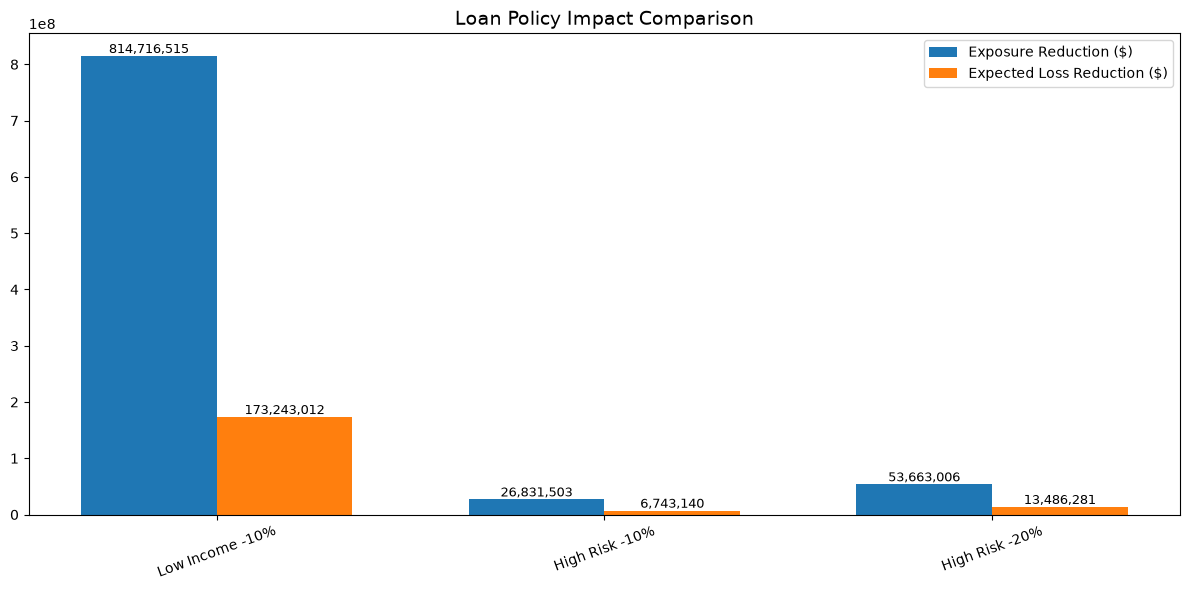

In [12]:

# Scenarios
scenarios = [
    "Low Income -10%",
    "High Risk -10%",
    "High Risk -20%"
]

# Example metrics from your results (use YOUR real values here)
exposure_reduction = [
    814_716_515,
    26_831_503,
    53_663_006
]

loss_reduction = [
    173_243_012,
    6_743_140,
    13_486_281
]

x = np.arange(len(scenarios))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(
    x - width/2,
    exposure_reduction,
    width,
    label="Exposure Reduction ($)"
)

bars2 = ax.bar(
    x + width/2,
    loss_reduction,
    width,
    label="Expected Loss Reduction ($)"
)

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:,.0f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)

ax.set_title("Loan Policy Impact Comparison", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(scenarios, rotation=20)
ax.legend()

plt.tight_layout()

plt.savefig(
    project_path / "visuals" / "loan_policy_impact_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


Strategy: Strategy 1 — Low Income, -10% cap
----------------------------------------
Default rate before cap : 17.66%
Default rate after cap  : 16.33%
Reduction               : 1.32%

Strategy: Strategy 2A — High Risk, -10% cap
----------------------------------------
Default rate before cap : 21.75%
Default rate after cap  : 20.61%
Reduction               : 1.14%

Strategy: Strategy 2B — High Risk, -20% cap
----------------------------------------
Default rate before cap : 21.75%
Default rate after cap  : 19.51%
Reduction               : 2.24%
            Strategy     Before      After  Reduction
0  Low Income (-10%)  17.656026  16.331586   1.324440
1   High Risk (-10%)  21.752829  20.610696   1.142132
2   High Risk (-20%)  21.752829  19.508991   2.243838


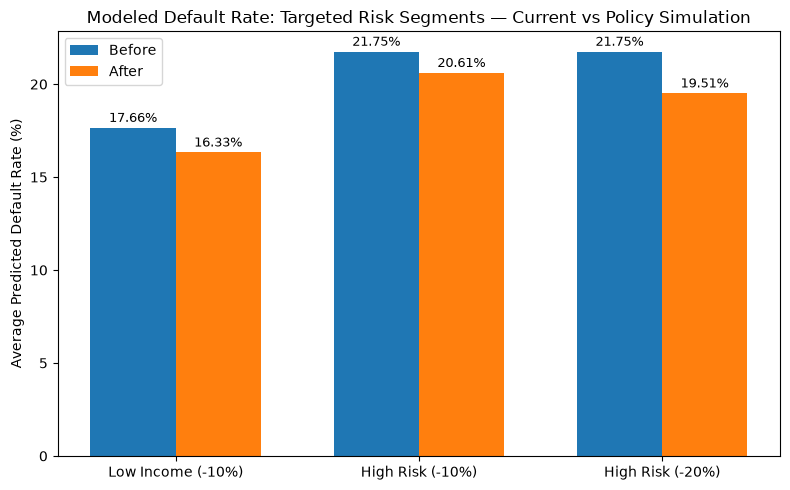

In [66]:

# Recalculate Default Rate for All 3 Strategies

def recalculate_default_rate(segment, cap, label):

    sim = segment.copy()

    # Apply loan cap
    sim["LoanAmount"] = sim["LoanAmount"] * cap

    # Recalculate features that depend on LoanAmount
    sim["Debt_burden"] = sim["LoanAmount"] / (sim["Income"] + 1)
    sim["Income_to_Loan"] = sim["Income"] / (sim["LoanAmount"] + 1)
    sim["Score_pressure"] = sim["LoanAmount"] / (sim["CreditScore"] + 1)

    # Prepare features for prediction
    X_new = sim.drop(
        ["LoanID", "Default", "Probability_of_Default", "IncomeSegment"],
        axis=1
    )

    X_new = pd.get_dummies(X_new, drop_first=True)

    X_new = X_new.reindex(
        columns=model.feature_names_in_,
        fill_value=0
    )

    # Predict new default probability
    sim["New_PD"] = model.predict_proba(X_new)[:, 1]

    # Compare before vs after
    old_rate = sim["Probability_of_Default"].mean() * 100
    new_rate = sim["New_PD"].mean() * 100

    print(f"\nStrategy: {label}")
    print("-" * 40)
    print(f"Default rate before cap : {old_rate:.2f}%")
    print(f"Default rate after cap  : {new_rate:.2f}%")
    print(f"Reduction               : {old_rate - new_rate:.2f}%")

    return old_rate, new_rate

# Strategy 1: Low Income, -10%

low_income = df[df["IncomeSegment"] == "Low"].copy()

before1, after1 = recalculate_default_rate(
    segment=low_income,
    cap=0.90,
    label="Strategy 1 — Low Income, -10% cap"
)

# Strategy 2: High Risk Segment

high_risk = df[
    (df["IncomeSegment"] == "Low") &
    (df["CreditScore"] < 350) &
    (df["DTIRatio"] > 0.60)
].copy()


# Strategy 2A (-10%)

before2, after2 = recalculate_default_rate(
    segment=high_risk,
    cap=0.90,
    label="Strategy 2A — High Risk, -10% cap"
)


# Strategy 2B (-20%)

before3, after3 = recalculate_default_rate(
    segment=high_risk,
    cap=0.80,
    label="Strategy 2B — High Risk, -20% cap"
)


# Summary Table

results = pd.DataFrame({
    "Strategy": [
        "Low Income (-10%)",
        "High Risk (-10%)",
        "High Risk (-20%)"
    ],
    "Before": [before1, before2, before3],
    "After": [after1, after2, after3]
})

results["Reduction"] = results["Before"] - results["After"]

print(results)

# Visualization

x = np.arange(len(results))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars_before = ax.bar(
    x - width/2,
    results["Before"],
    width,
    label="Before"
)

bars_after = ax.bar(
    x + width/2,
    results["After"],
    width,
    label="After"
)

# Add values above bars
for bar in bars_before:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars_after:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xticks(x)
ax.set_xticklabels(results["Strategy"])
ax.set_ylabel("Average Predicted Default Rate (%)")
ax.set_title("Modeled Default Rate: Targeted Risk Segments — Current vs Policy Simulation")
ax.legend()

plt.tight_layout()

plt.savefig(
    project_path / "visuals" / "default_rate_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

          Scenario  Portfolio_PD  Reduction_vs_Baseline
0  Low Income -25%     10.959738               0.792294
1   High Risk -20%     11.733500               0.018533
2   High Risk -30%     11.724787               0.027246


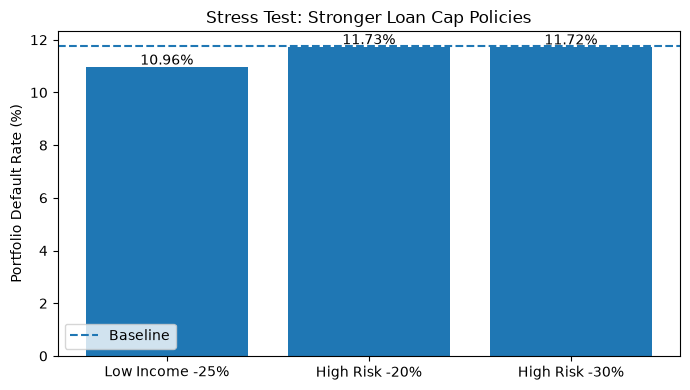

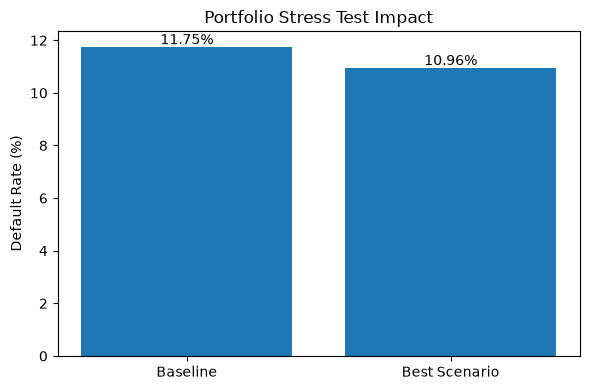

In [73]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# BASELINE
# ============================================================

baseline_pd = df["Probability_of_Default"].mean() * 100


# ============================================================
# PORTFOLIO SIMULATION FUNCTION
# ============================================================

def simulate_portfolio(df_input, low_cap=None, high_cap=None):

    sim = df_input.copy()

    sim["LoanAmount"] = sim["LoanAmount"].astype(float)
    sim["PD"] = sim["Probability_of_Default"]

    # ========================================================
    # LOW INCOME POLICY
    # ========================================================
    if low_cap is not None:

        mask_low = sim["IncomeSegment"] == "Low"

        sim.loc[mask_low, "LoanAmount"] *= low_cap

        sim.loc[mask_low, "Debt_burden"] = sim.loc[mask_low, "LoanAmount"] / (sim.loc[mask_low, "Income"] + 1)
        sim.loc[mask_low, "Income_to_Loan"] = sim.loc[mask_low, "Income"] / (sim.loc[mask_low, "LoanAmount"] + 1)
        sim.loc[mask_low, "Score_pressure"] = sim.loc[mask_low, "LoanAmount"] / (sim.loc[mask_low, "CreditScore"] + 1)

        X_low = sim.loc[mask_low].drop(
            ["LoanID", "Default", "Probability_of_Default", "IncomeSegment", "PD"],
            axis=1
        )

        X_low = pd.get_dummies(X_low, drop_first=True)
        X_low = X_low.reindex(columns=model.feature_names_in_, fill_value=0)

        sim.loc[mask_low, "PD"] = model.predict_proba(X_low)[:, 1]


    # ========================================================
    # HIGH RISK POLICY
    # ========================================================
    if high_cap is not None:

        mask_high = (
            (sim["IncomeSegment"] == "Low") &
            (sim["CreditScore"] < 350) &
            (sim["DTIRatio"] > 0.60)
        )

        sim.loc[mask_high, "LoanAmount"] *= high_cap

        sim.loc[mask_high, "Debt_burden"] = sim.loc[mask_high, "LoanAmount"] / (sim.loc[mask_high, "Income"] + 1)
        sim.loc[mask_high, "Income_to_Loan"] = sim.loc[mask_high, "Income"] / (sim.loc[mask_high, "LoanAmount"] + 1)
        sim.loc[mask_high, "Score_pressure"] = sim.loc[mask_high, "LoanAmount"] / (sim.loc[mask_high, "CreditScore"] + 1)

        X_high = sim.loc[mask_high].drop(
            ["LoanID", "Default", "Probability_of_Default", "IncomeSegment", "PD"],
            axis=1
        )

        X_high = pd.get_dummies(X_high, drop_first=True)
        X_high = X_high.reindex(columns=model.feature_names_in_, fill_value=0)

        sim.loc[mask_high, "PD"] = model.predict_proba(X_high)[:, 1]


    return sim["PD"].mean() * 100


# ============================================================
# STRESS TEST SCENARIOS (STRONGER POLICIES)
# ============================================================

portfolio_25 = simulate_portfolio(df, low_cap=0.75, high_cap=None)  # -25%
portfolio_20 = simulate_portfolio(df, low_cap=None, high_cap=0.80)  # -20%
portfolio_30 = simulate_portfolio(df, low_cap=None, high_cap=0.70)  # -30%


# ============================================================
# RESULTS TABLE
# ============================================================

results = pd.DataFrame({
    "Scenario": [
        "Low Income -25%",
        "High Risk -20%",
        "High Risk -30%"
    ],
    "Portfolio_PD": [
        portfolio_25,
        portfolio_20,
        portfolio_30
    ]
})

results["Reduction_vs_Baseline"] = baseline_pd - results["Portfolio_PD"]

print(results)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(7,4))

plt.bar(results["Scenario"], results["Portfolio_PD"])

plt.axhline(baseline_pd, linestyle="--", label="Baseline")

for i, v in enumerate(results["Portfolio_PD"]):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha="center")

plt.ylabel("Portfolio Default Rate (%)")
plt.title("Stress Test: Stronger Loan Cap Policies")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# SAVE PLOT
# ============================================================

plt.figure(figsize=(6,4))

plt.bar(
    ["Baseline", "Best Scenario"],
    [baseline_pd, min(results["Portfolio_PD"])]
)

for i, v in enumerate([baseline_pd, min(results["Portfolio_PD"])]):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha="center")

plt.ylabel("Default Rate (%)")
plt.title("Portfolio Stress Test Impact")

plt.tight_layout()

plt.savefig(
    project_path / "visuals" / "portfolio_stress_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [95]:


fi = pd.DataFrame({
    "feature": model.feature_names_in_,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(fi.head(15))

AttributeError: 'LogisticRegression' object has no attribute 'feature_importances_'